C:\Users\eucli\AppData\Local\Temp\ipykernel_4476\3064218426.py:20: UserWarning: The filter's denominator is extremely small at frequencies [3.108, 3.108, 3.109, 3.109, 3.109, 3.110, 3.110, 3.111, 3.111, 3.111, 3.112, 3.112, 3.113, 3.113, 3.113, 3.114, 3.114, 3.114, 3.115, 3.115, 3.116, 3.116, 3.116, 3.117, 3.117, 3.118, 3.118, 3.118, 3.119, 3.119, 3.120, 3.120, 3.120, 3.121, 3.121, 3.122, 3.122, 3.122, 3.123, 3.123, 3.124, 3.124, 3.124, 3.125, 3.125, 3.125, 3.126, 3.126, 3.127, 3.127, 3.127, 3.128, 3.128, 3.129, 3.129, 3.129, 3.130, 3.130, 3.131, 3.131, 3.131, 3.132, 3.132, 3.133, 3.133, 3.133, 3.134, 3.134, 3.135, 3.135, 3.135, 3.136, 3.136, 3.136, 3.137, 3.137, 3.138, 3.138, 3.138, 3.139, 3.139, 3.140, 3.140, 3.140, 3.141, 3.141], around which a singularity may be present
  _, gd_iir = signal.group_delay((b_iir, a_iir), w=w_iir, fs=fs)


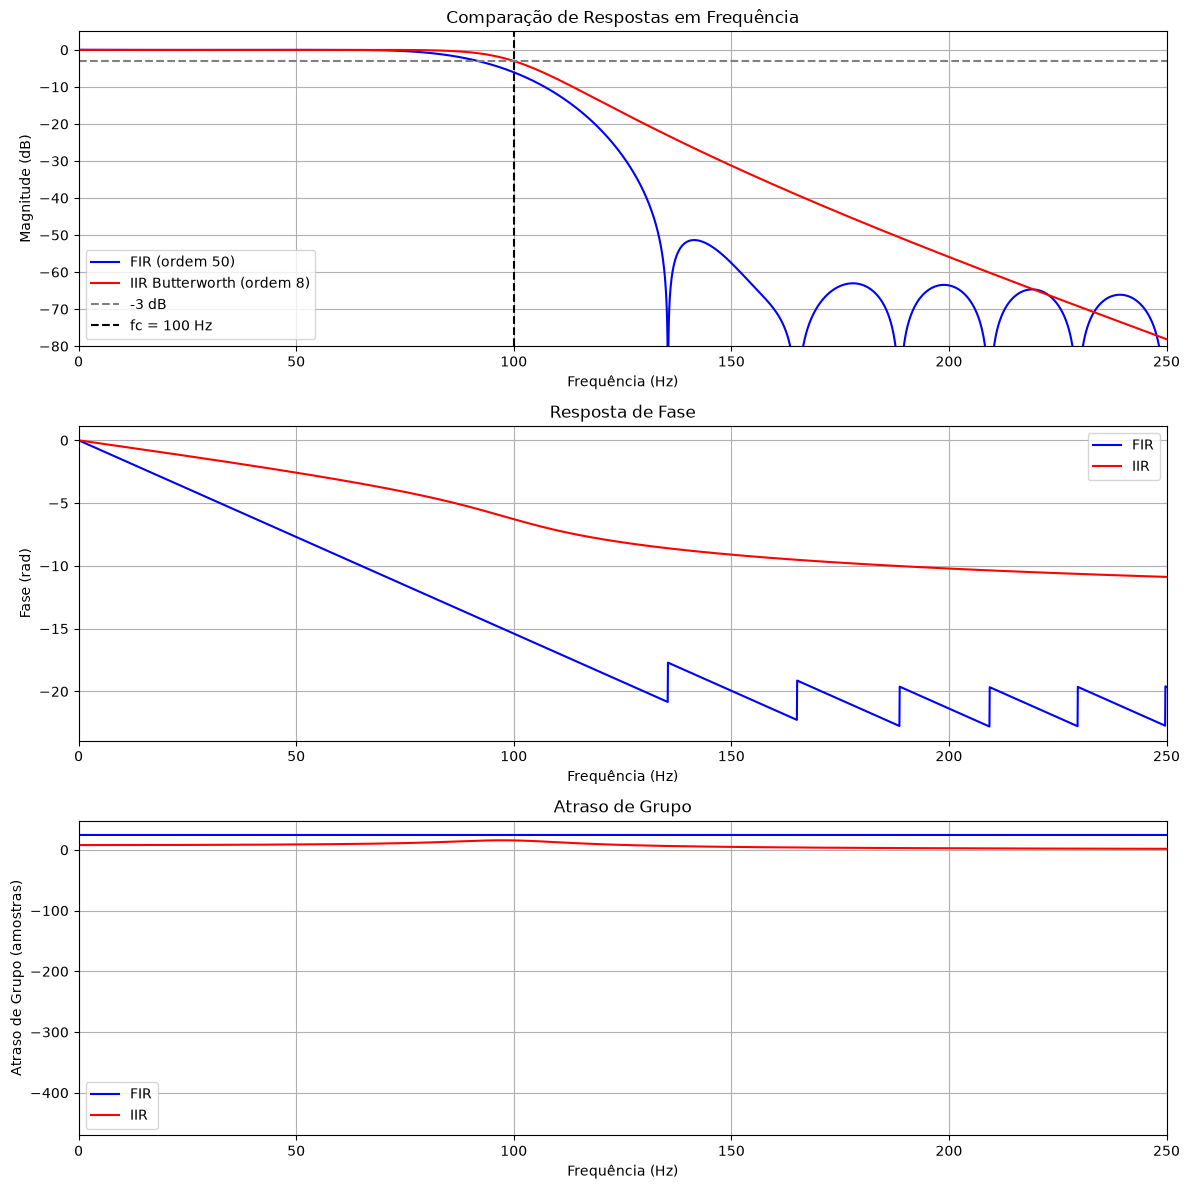

Ondulação na banda de passagem (FIR): 6.028 dB
Ondulação na banda de passagem (IIR): 2.987 dB
Atenuação na banda de rejeição (FIR): -141.84 dB
Atenuação na banda de rejeição (IIR): -200.00 dB


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# Parâmetros
fs = 1000
fc = 100  # Frequência de corte (Hz)
ordem = 50

# Projeto dos filtros com frequências de corte similares
b_fir = signal.firwin(ordem, fc, fs=fs, window='hamming')
b_iir, a_iir = signal.butter(8, fc, fs=fs, btype='low')

# Respostas em frequência
w_fir, h_fir = signal.freqz(b_fir, [1.0], worN=8000, fs=fs)
w_iir, h_iir = signal.freqz(b_iir, a_iir, worN=8000, fs=fs)

# Atraso de grupo
_, gd_fir = signal.group_delay((b_fir, [1.0]), w=w_fir, fs=fs)
_, gd_iir = signal.group_delay((b_iir, a_iir), w=w_iir, fs=fs)

# Gráficos
fig, axes = plt.subplots(3, 1, figsize=(12, 12))

# Magnitude
axes[0].plot(w_fir, 20*np.log10(np.abs(h_fir) + 1e-10), 'b', label='FIR (ordem 50)')
axes[0].plot(w_iir, 20*np.log10(np.abs(h_iir) + 1e-10), 'r', label='IIR Butterworth (ordem 8)')
axes[0].axhline(-3, color='gray', linestyle='--', label='-3 dB')
axes[0].axvline(fc, color='k', linestyle='--', label=f'fc = {fc} Hz')
axes[0].set_xlabel('Frequência (Hz)')
axes[0].set_ylabel('Magnitude (dB)')
axes[0].set_title('Comparação de Respostas em Frequência')
axes[0].set_xlim(0, 250)
axes[0].set_ylim(-80, 5)
axes[0].legend()
axes[0].grid()

# Fase
axes[1].plot(w_fir, np.unwrap(np.angle(h_fir)), 'b', label='FIR')
axes[1].plot(w_iir, np.unwrap(np.angle(h_iir)), 'r', label='IIR')
axes[1].set_xlabel('Frequência (Hz)')
axes[1].set_ylabel('Fase (rad)')
axes[1].set_title('Resposta de Fase')
axes[1].set_xlim(0, 250)
axes[1].legend()
axes[1].grid()

# Atraso de grupo
axes[2].plot(w_fir, gd_fir, 'b', label='FIR')
axes[2].plot(w_iir, gd_iir, 'r', label='IIR')
axes[2].set_xlabel('Frequência (Hz)')
axes[2].set_ylabel('Atraso de Grupo (amostras)')
axes[2].set_title('Atraso de Grupo')
axes[2].set_xlim(0, 250)
axes[2].legend()
axes[2].grid()

plt.tight_layout()
plt.show()

# Comparação na banda de passagem
idx_pass = w_fir < fc
ripple_fir = np.max(20*np.log10(np.abs(h_fir[idx_pass]) + 1e-10)) - np.min(20*np.log10(np.abs(h_fir[idx_pass]) + 1e-10))
ripple_iir = np.max(20*np.log10(np.abs(h_iir[idx_pass]) + 1e-10)) - np.min(20*np.log10(np.abs(h_iir[idx_pass]) + 1e-10))

print(f"Ondulação na banda de passagem (FIR): {ripple_fir:.3f} dB")
print(f"Ondulação na banda de passagem (IIR): {ripple_iir:.3f} dB")
print(f"Atenuação na banda de rejeição (FIR): {20*np.log10(np.abs(h_fir[-1]) + 1e-10):.2f} dB")
print(f"Atenuação na banda de rejeição (IIR): {20*np.log10(np.abs(h_iir[-1]) + 1e-10):.2f} dB")

# Discussão dos Resultados
O filtro IIR de ordem 8 apresenta transição mais abrupta e maior atenuação na banda de rejeição que o FIR de ordem 50, demonstrando a superior seletividade dos filtros IIR para mesma ordem. No entanto, a fase do IIR é não linear, resultando em atraso de grupo variável. O FIR mantém fase linear com atraso de grupo constante, garantindo preservação da forma do sinal na banda de passagem.